In [11]:
import pandas as pd

df = pd.read_csv('../data/Walmart.csv')

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [12]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [14]:
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

weekly_sales['Weekly_Sales'] = pd.to_numeric(
    weekly_sales['Weekly_Sales'],
    errors='coerce'
)

weekly_sales.columns = ['ds', 'y']

In [15]:
weekly_sales['y'] = weekly_sales['y'].astype(float)


In [16]:
weekly_sales['y'] = weekly_sales['y'] / 1000000

In [17]:
!pip install prophet


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from prophet import Prophet

model = Prophet()
model.fit(weekly_sales)

future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

18:50:52 - cmdstanpy - INFO - Chain [1] start processing
18:50:52 - cmdstanpy - INFO - Chain [1] done processing


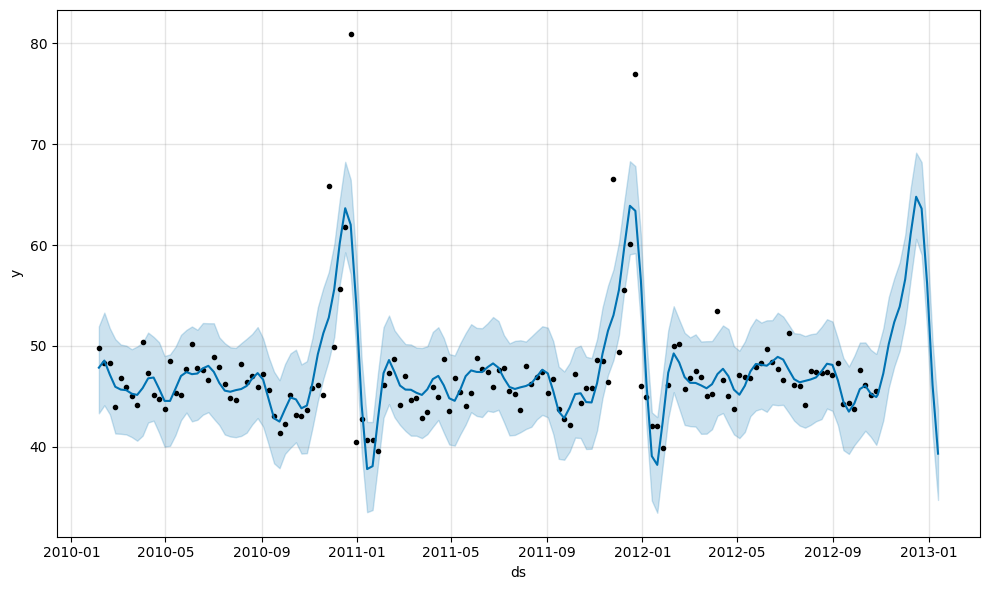

In [19]:
import matplotlib.pyplot as plt

model.plot(forecast)
plt.show()

In [20]:
forecast[['ds','yhat']].to_csv('../data/forecast.csv', index=False)